# 6. Interpret Target-Limited Harmonic Trends

This notebook turns notebook 5's analysis outputs into a small set of interpretable harmonic-trend findings.

It does not rebuild the database or recompute n-gram counts. It reads the all-n candidate tables from `data/processed/analysis/`, filters them for support, then groups related `n`-gram variants into progression families. The family layer is the main reading surface; the detailed rows remain available for audit and follow-up.


## Pipeline Role

This notebook turns notebook 5's target-limited results into interpretable candidate findings.

It is the end of the lightweight trend-inspection branch. The next branch starts in notebook 7, where we build broader harmonic document-term counts for corpus-linguistic analysis.

## Interpretation Goals

The goal here is not to make final musicological claims yet. The goal is to identify strong candidate patterns worth deeper study:

1. Harmonic families that declined by decade.
2. Harmonic families that rose by decade.
3. Genre-specific harmonic families with enough support.
4. Exact representatives that dominate or fragment within important harmonic classes.
5. A short, family-level checklist of findings to inspect manually.

A family is a readable grouping of related `H_n` rows. For repeated progressions like `G C G C G`, the family label becomes a shorter loop label such as `G C loop`. For non-repeating progressions, the label uses the first few chords as a phrase label.


In [1]:
from pathlib import Path
import importlib
import os
import sys

CWD = Path.cwd()
ROOT = CWD.parent if (CWD / "utils").exists() else CWD
MPLCONFIGDIR = ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

NOTEBOOK_DIR = ROOT / "notebooks"

# Force this repo's notebook utilities to win over any stale or external `utils` package.
sys.path = [p for p in sys.path if p != str(NOTEBOOK_DIR)]
sys.path.insert(0, str(NOTEBOOK_DIR))
for module_name in list(sys.modules):
    if module_name == "utils" or module_name.startswith("utils."):
        del sys.modules[module_name]

from utils import duckdb_store as ds

ds = importlib.reload(ds)
expected_duckdb_store = (NOTEBOOK_DIR / "utils" / "duckdb_store.py").resolve()
loaded_duckdb_store = Path(ds.__file__).resolve()
assert loaded_duckdb_store == expected_duckdb_store, f"Imported wrong duckdb_store module: {loaded_duckdb_store}; expected {expected_duckdb_store}"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)


def short_harmonic_label(example: str, harmonic_id: str) -> str:
    suffix = str(harmonic_id).split("_", 1)[-1][:6]
    return f"{example} ({suffix})"


def progression_family_parts(label: str, max_phrase_len: int = 3) -> tuple[str, str, str]:
    """Return a readable family key, label, and kind for an n-gram label."""
    tokens = str(label).split()
    if not tokens:
        return "", "", "empty"

    max_period = min(max_phrase_len, max(1, len(tokens) - 1))
    for period_len in range(1, max_period + 1):
        seed = tokens[:period_len]
        if len(tokens) > period_len and all(tokens[i] == seed[i % period_len] for i in range(len(tokens))):
            key = " ".join(seed)
            return key, f"{key} loop", "loop"

    seed = tokens[: min(max_phrase_len, len(tokens))]
    key = " ".join(seed)
    return key, key, "phrase"


def add_family_columns(df: pd.DataFrame, label_col: str = "representative_example_ngram") -> pd.DataFrame:
    out = df.copy()
    parts = out[label_col].map(progression_family_parts)
    out["family_key"] = parts.map(lambda x: x[0])
    out["family_label"] = parts.map(lambda x: x[1])
    out["family_kind"] = parts.map(lambda x: x[2])
    return out


def compact_n_values(values) -> str:
    return ",".join(str(int(v)) for v in sorted(set(values)))


def summarize_decade_families(rows: pd.DataFrame) -> pd.DataFrame:
    if rows.empty:
        return pd.DataFrame()

    rows = add_family_columns(rows)
    rows["abs_delta"] = rows["frequency_delta"].abs()
    best_idx = rows.groupby(["trend_direction", "family_key"])["abs_delta"].idxmax()
    best = rows.loc[best_idx].copy()

    aggregates = (
        rows.groupby(["trend_direction", "family_key"], as_index=False)
        .agg(
            family_label=("family_label", "first"),
            family_kind=("family_kind", "first"),
            n_values=("n", compact_n_values),
            max_abs_delta=("abs_delta", "max"),
            n_rows=("harmonic_id", "nunique"),
        )
    )

    best_cols = [
        "trend_direction",
        "family_key",
        "n",
        "harmonic_id",
        "representative_example_ngram",
        "first_decade",
        "last_decade",
        "first_frequency",
        "last_frequency",
        "frequency_delta",
        "frequency_ratio",
        "first_count",
        "last_count",
    ]
    out = aggregates.merge(best[best_cols], on=["trend_direction", "family_key"], how="left")
    return out.sort_values(["trend_direction", "max_abs_delta"], ascending=[True, False]).reset_index(drop=True)


def summarize_genre_families(rows: pd.DataFrame) -> pd.DataFrame:
    if rows.empty:
        return pd.DataFrame()

    rows = add_family_columns(rows)
    best_idx = rows.groupby(["main_genre", "family_key"])["genre_lift"].idxmax()
    best = rows.loc[best_idx].copy()

    aggregates = (
        rows.groupby(["main_genre", "family_key"], as_index=False)
        .agg(
            family_label=("family_label", "first"),
            family_kind=("family_kind", "first"),
            n_values=("n", compact_n_values),
            max_genre_lift=("genre_lift", "max"),
            n_rows=("harmonic_id", "nunique"),
        )
    )

    best_cols = [
        "main_genre",
        "family_key",
        "n",
        "harmonic_id",
        "representative_example_ngram",
        "count",
        "total_windows",
        "frequency",
        "other_genre_frequency",
        "genre_lift",
    ]
    out = aggregates.merge(best[best_cols], on=["main_genre", "family_key"], how="left")
    return out.sort_values(["main_genre", "max_genre_lift"], ascending=[True, False]).reset_index(drop=True)

{
    "python": sys.executable,
    "duckdb_version": duckdb.__version__,
    "duckdb_store": str(loaded_duckdb_store),
}

{'python': '/usr/local/bin/python3',
 'duckdb_version': '1.5.2',
 'duckdb_store': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/duckdb_store.py'}

In [2]:
ANALYSIS_DIR = ROOT / "data" / "processed" / "analysis"
DB_PATH = ROOT / "data" / "processed" / "harmonic_trends.duckdb"

NS = tuple(range(3, 9))
MIN_SUPPORT_COUNT = 500
MIN_ABS_DELTA = 0.0025
MIN_GENRE_LIFT = 2.0
TOP_K = 15

required_files = {
    "decade_shifts": ANALYSIS_DIR / "H_all_decade_shifts.csv",
    "genre_specificity": ANALYSIS_DIR / "H_all_genre_specificity.csv",
    "top_targets": ANALYSIS_DIR / "H_all_top_targets.csv",
    "representatives_by_decade": ANALYSIS_DIR / "H_all_top_representatives_by_decade.csv",
    "representatives_by_genre": ANALYSIS_DIR / "H_all_top_representatives_by_genre.csv",
    "high_share": ANALYSIS_DIR / "V_all_exact_harmonic_high_share.csv",
    "low_share": ANALYSIS_DIR / "V_all_exact_harmonic_low_share.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
assert not missing, f"Run notebook 5 first. Missing files: {missing}"
assert DB_PATH.exists(), DB_PATH
ANALYSIS_DIR

PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis')

## Load Candidate Tables

These are small report-oriented tables generated by notebook 5. The database remains the source of truth for counted data, but these tables are convenient for interpretation and manual reading.

In [3]:
decade_shifts = pd.read_csv(required_files["decade_shifts"])
genre_specificity = pd.read_csv(required_files["genre_specificity"])
top_targets = pd.read_csv(required_files["top_targets"])
representatives_by_decade = pd.read_csv(required_files["representatives_by_decade"])
representatives_by_genre = pd.read_csv(required_files["representatives_by_genre"])
high_share = pd.read_csv(required_files["high_share"])
low_share = pd.read_csv(required_files["low_share"])

{
    "decade_shifts": decade_shifts.shape,
    "genre_specificity": genre_specificity.shape,
    "top_targets": top_targets.shape,
    "representatives_by_decade": representatives_by_decade.shape,
    "representatives_by_genre": representatives_by_genre.shape,
    "high_share": high_share.shape,
    "low_share": low_share.shape,
}

{'decade_shifts': (150, 12),
 'genre_specificity': (150, 10),
 'top_targets': (6, 5),
 'representatives_by_decade': (268, 9),
 'representatives_by_genre': (372, 9),
 'high_share': (150, 14),
 'low_share': (150, 14)}

## Supported Decade Declines

These are harmonic classes whose frequency fell from their first qualifying decade to their last qualifying decade. The support filter uses both endpoint counts.

In [4]:
supported_decade = decade_shifts[
    (decade_shifts["first_count"] >= MIN_SUPPORT_COUNT)
    & (decade_shifts["last_count"] >= MIN_SUPPORT_COUNT)
    & (decade_shifts["frequency_delta"].abs() >= MIN_ABS_DELTA)
].copy()

largest_declines = (
    supported_decade[supported_decade["frequency_delta"] < 0]
    .sort_values(["n", "frequency_delta"])
    .groupby("n", as_index=False)
    .head(TOP_K)
)

largest_declines[[
    "n",
    "harmonic_id",
    "representative_example_ngram",
    "first_decade",
    "last_decade",
    "first_frequency",
    "last_frequency",
    "frequency_delta",
    "frequency_ratio",
    "first_count",
    "last_count",
]]

,n,harmonic_id,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,frequency_ratio,first_count,last_count
0,3,H3_ede3c4f53675bbb0,G C G,1950,2020,0.077958,0.036051,-0.041908,0.462433,7478,150418
1,3,H3_35d6bfda85b78e3b,C G C,1950,2020,0.065438,0.031584,-0.033854,0.482654,6277,131781
2,3,H3_3569c7a41696606d,C G7 C,1950,2020,0.028481,0.001606,-0.026875,0.056389,2732,6701
6,3,H3_c7a280c94f7b2c52,D7 G C,1950,2020,0.019464,0.001486,-0.017978,0.076345,1867,6200
8,3,H3_614d8a0823c338e1,D G C,1950,2020,0.034955,0.019988,-0.014967,0.571810,3353,83397
9,3,H3_1bdd33c6de808e91,G G7 C,1950,2020,0.015919,0.001829,-0.014090,0.114904,1527,7632
10,3,H3_e22461c759d5715e,G7 C G7,1950,2020,0.013897,0.000826,-0.013070,0.059466,1333,3448
13,3,H3_399df86a5aae7301,F C G7,1950,2020,0.012468,0.000793,-0.011675,0.063606,1196,3309
24,3,H3_ea27575f6512821d,C D7 G,1950,2020,0.008705,0.000883,-0.007822,0.101458,835,3685
25,4,H4_f6775591139fd92b,G C G C,1950,2020,0.036422,0.016423,-0.019999,0.450903,3430,67642


## Supported Decade Rises

These are harmonic classes whose frequency increased most over time.

In [5]:
largest_rises = (
    supported_decade[supported_decade["frequency_delta"] > 0]
    .sort_values(["n", "frequency_delta"], ascending=[True, False])
    .groupby("n", as_index=False)
    .head(TOP_K)
)

largest_rises[[
    "n",
    "harmonic_id",
    "representative_example_ngram",
    "first_decade",
    "last_decade",
    "first_frequency",
    "last_frequency",
    "frequency_delta",
    "frequency_ratio",
    "first_count",
    "last_count",
]]

,n,harmonic_id,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,frequency_ratio,first_count,last_count
5,3,H3_950fb5de7bd72a8d,G Amin F,1960,2020,0.001993,0.020629,0.018636,10.351589,1168,86074
11,3,H3_0859351c7b2e5686,D C G,1950,2020,0.009560,0.021958,0.012398,2.296897,917,91617
14,3,H3_4e99eecf61b0edec,C G D,1950,2020,0.026709,0.038340,0.011631,1.435461,2562,159969
15,3,H3_908053190bacc7d7,F G Amin,1960,2020,0.002728,0.013788,0.011059,5.053691,1599,57528
19,3,H3_2bd39a67fe3535a8,G D C,1950,2020,0.008976,0.018004,0.009028,2.005852,861,75122
40,4,H4_e498ff144f418da0,G Amin F G,1960,2020,0.000909,0.005628,0.004720,6.193386,524,23182
42,4,H4_6f7528dbba7be76e,C G D C,1950,2020,0.006360,0.010872,0.004512,1.709374,599,44782
71,5,H5_fe03e54f5e258a8a,Amin G F Amin G,1970,2020,0.000727,0.003763,0.003035,5.173239,855,15297
73,5,H5_3f271b6cbfd476a8,C G D C G,1950,2020,0.005767,0.008768,0.003001,1.520478,533,35645
76,6,H6_6a56c71e698afea8,F C G Amin F C,1970,2020,0.000664,0.010473,0.009809,15.769525,770,42016


## Visual Summary: Rises vs Declines

This plot shows the strongest supported decade changes by `n`. It is intended as a triage view: the table above remains the exact source.

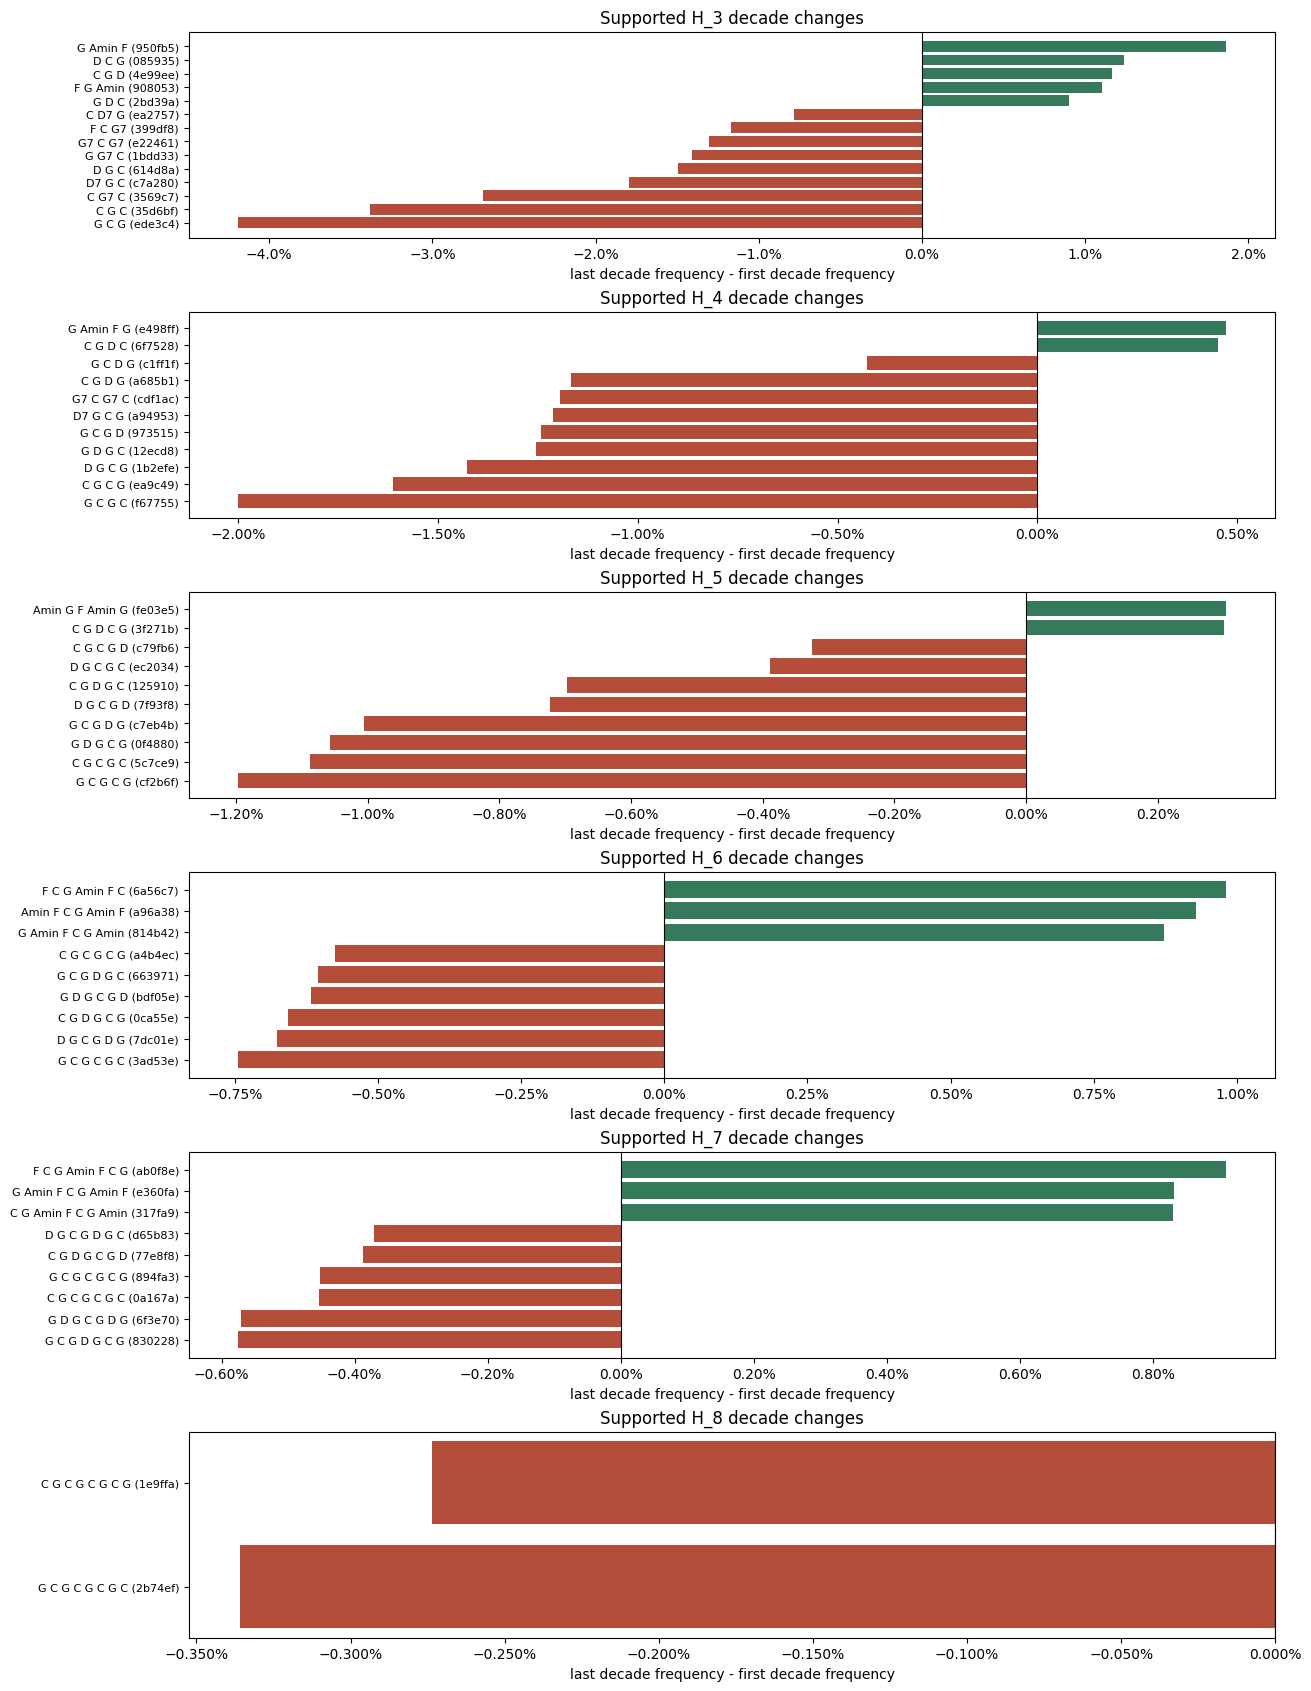

In [6]:
plot_df = pd.concat(
    [
        largest_declines.assign(direction="decline"),
        largest_rises.assign(direction="rise"),
    ],
    ignore_index=True,
)
plot_df = plot_df.sort_values(["n", "frequency_delta"])
plot_df["label"] = [
    short_harmonic_label(example, harmonic_id)
    for example, harmonic_id in zip(plot_df["representative_example_ngram"], plot_df["harmonic_id"])
]

fig, axes = plt.subplots(len(NS), 1, figsize=(13, 2.8 * len(NS)), constrained_layout=True)
if len(NS) == 1:
    axes = [axes]

for ax, n in zip(axes, NS):
    sub = plot_df[plot_df["n"] == n].copy()
    if sub.empty:
        ax.set_title(f"No supported H_{n} decade changes with current filters")
        ax.axis("off")
        continue
    sub = sub.sort_values("frequency_delta")
    colors = ["#b44e3a" if v < 0 else "#347a5b" for v in sub["frequency_delta"]]
    ax.barh(sub["label"], sub["frequency_delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Supported H_{n} decade changes")
    ax.set_xlabel("last decade frequency - first decade frequency")
    ax.tick_params(axis="y", labelsize=8)

plt.show()

## Supported Genre-Specific Patterns

These candidates have high genre lift and enough raw count support. Treat them as leads, not final claims.

In [7]:
supported_genre = genre_specificity[
    (genre_specificity["count"] >= MIN_SUPPORT_COUNT)
    & (genre_specificity["genre_lift"] >= MIN_GENRE_LIFT)
].copy()

supported_genre_top = (
    supported_genre
    .sort_values(["n", "genre_lift", "count"], ascending=[True, False, False])
    .groupby("n", as_index=False)
    .head(TOP_K)
)

supported_genre_top[[
    "n",
    "main_genre",
    "harmonic_id",
    "representative_example_ngram",
    "count",
    "total_windows",
    "frequency",
    "other_genre_frequency",
    "genre_lift",
]]

,n,main_genre,harmonic_id,representative_example_ngram,count,total_windows,frequency,other_genre_frequency,genre_lift
0,3,country,H3_399df86a5aae7301,F C G7,20483,3693669,0.005545,0.000858,6.460602
1,3,country,H3_c7a280c94f7b2c52,D7 G C,32125,3693669,0.008697,0.001670,5.209340
2,3,reggae,H3_c6c2d59fbc9ff943,Amin Emin Amin,5542,273138,0.020290,0.003929,5.164374
3,3,country,H3_3569c7a41696606d,C G7 C,34861,3693669,0.009438,0.001853,5.093976
4,3,reggae,H3_50e7ed727fe7c489,Emin Amin Emin,6131,273138,0.022447,0.004618,4.860192
...,...,...,...,...,...,...,...,...,...
135,8,reggae,H8_cf107565d1eb7452,D G Emin Amin D G Emin Amin,696,254013,0.002740,0.000566,4.842986
136,8,reggae,H8_e1b1c5c6019955c9,Amin D G Emin Amin D G Emin,663,254013,0.002610,0.000547,4.770223
137,8,reggae,H8_19f9cbead3765746,Emin Amin D G Emin Amin D G,691,254013,0.002720,0.000582,4.670377
138,8,reggae,H8_263105bbb9f27661,G Emin Amin D G Emin Amin D,733,254013,0.002886,0.000624,4.621925


## Family-Level Trend Summaries

The rows above are still `H_n` classes. This section collapses repeated or closely related `n`-gram variants into readable families so the same musical idea is not repeated six times.


In [8]:
decade_family_input = pd.concat(
    [
        largest_declines.assign(trend_direction="decline"),
        largest_rises.assign(trend_direction="rise"),
    ],
    ignore_index=True,
)

decade_trend_families = summarize_decade_families(decade_family_input)
genre_trend_families = summarize_genre_families(supported_genre_top)

{
    "decade_trend_families": decade_trend_families.shape,
    "genre_trend_families": genre_trend_families.shape,
}


{'decade_trend_families': (23, 18), 'genre_trend_families': (32, 15)}

In [9]:
decade_trend_families[[
    "trend_direction",
    "family_label",
    "family_kind",
    "n_values",
    "n_rows",
    "representative_example_ngram",
    "first_decade",
    "last_decade",
    "first_frequency",
    "last_frequency",
    "frequency_delta",
    "first_count",
    "last_count",
]].head(20)


,trend_direction,family_label,family_kind,n_values,n_rows,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,first_count,last_count
0,decline,G C loop,loop,"3,4,5,6,7,8",6,G C G,1950,2020,0.077958,0.036051,-0.041908,7478,150418
1,decline,C G loop,loop,"3,4,5,6,7,8",6,C G C,1950,2020,0.065438,0.031584,-0.033854,6277,131781
2,decline,C G7 loop,loop,3,1,C G7 C,1950,2020,0.028481,0.001606,-0.026875,2732,6701
3,decline,D7 G C,phrase,"3,4",2,D7 G C,1950,2020,0.019464,0.001486,-0.017978,1867,6200
4,decline,D G C,phrase,"3,4,5,6,7",6,D G C,1950,2020,0.034955,0.019988,-0.014967,3353,83397
5,decline,G G7 C,phrase,3,1,G G7 C,1950,2020,0.015919,0.001829,-0.014090,1527,7632
6,decline,G7 C loop,loop,"3,4",2,G7 C G7,1950,2020,0.013897,0.000826,-0.013070,1333,3448
7,decline,G D G,phrase,"4,5,6,7",4,G D G C,1950,2020,0.017531,0.004973,-0.012558,1651,20484
8,decline,G C G,phrase,"4,5,6,7",4,G C G D,1950,2020,0.019092,0.006666,-0.012426,1798,27457
9,decline,F C G7,phrase,3,1,F C G7,1950,2020,0.012468,0.000793,-0.011675,1196,3309


In [10]:
genre_trend_families[[
    "main_genre",
    "family_label",
    "family_kind",
    "n_values",
    "n_rows",
    "representative_example_ngram",
    "count",
    "total_windows",
    "frequency",
    "other_genre_frequency",
    "genre_lift",
]].head(24)


,main_genre,family_label,family_kind,n_values,n_rows,representative_example_ngram,count,total_windows,frequency,other_genre_frequency,genre_lift
0,country,D7 G C,phrase,"3,4",2,D7 G C G,19382,3640372,0.005324,0.000792,6.718214
1,country,F C G7,phrase,3,1,F C G7,20483,3693669,0.005545,0.000858,6.460602
2,country,C G7 loop,loop,3,1,C G7 C,34861,3693669,0.009438,0.001853,5.093976
3,country,G C G,phrase,"4,5,6,7",6,G C G D G D G,6525,3480588,0.001875,0.000421,4.448107
4,country,C G C,phrase,"6,7,8",3,C G C G D G C G,6524,3427416,0.001903,0.000430,4.424464
5,country,C D7 G,phrase,3,1,C D7 G,15617,3693669,0.004228,0.001007,4.198188
6,country,C G D,phrase,"4,5,6,7",4,C G D G C G C,7389,3480588,0.002123,0.000506,4.191997
7,country,G7 C loop,loop,"3,4",2,G7 C G7 C,12200,3640372,0.003351,0.000817,4.103623
8,country,G D G,phrase,"4,5,6",3,G D G C G C,10217,3533818,0.002891,0.000712,4.059034
9,country,D G C,phrase,"4,5,6",3,D G C G D G,34291,3533818,0.009704,0.002419,4.011531


## Visual Summary: Genre Lift

A log scale makes the lift ratios readable. The vertical reference line at 1 means no lift.

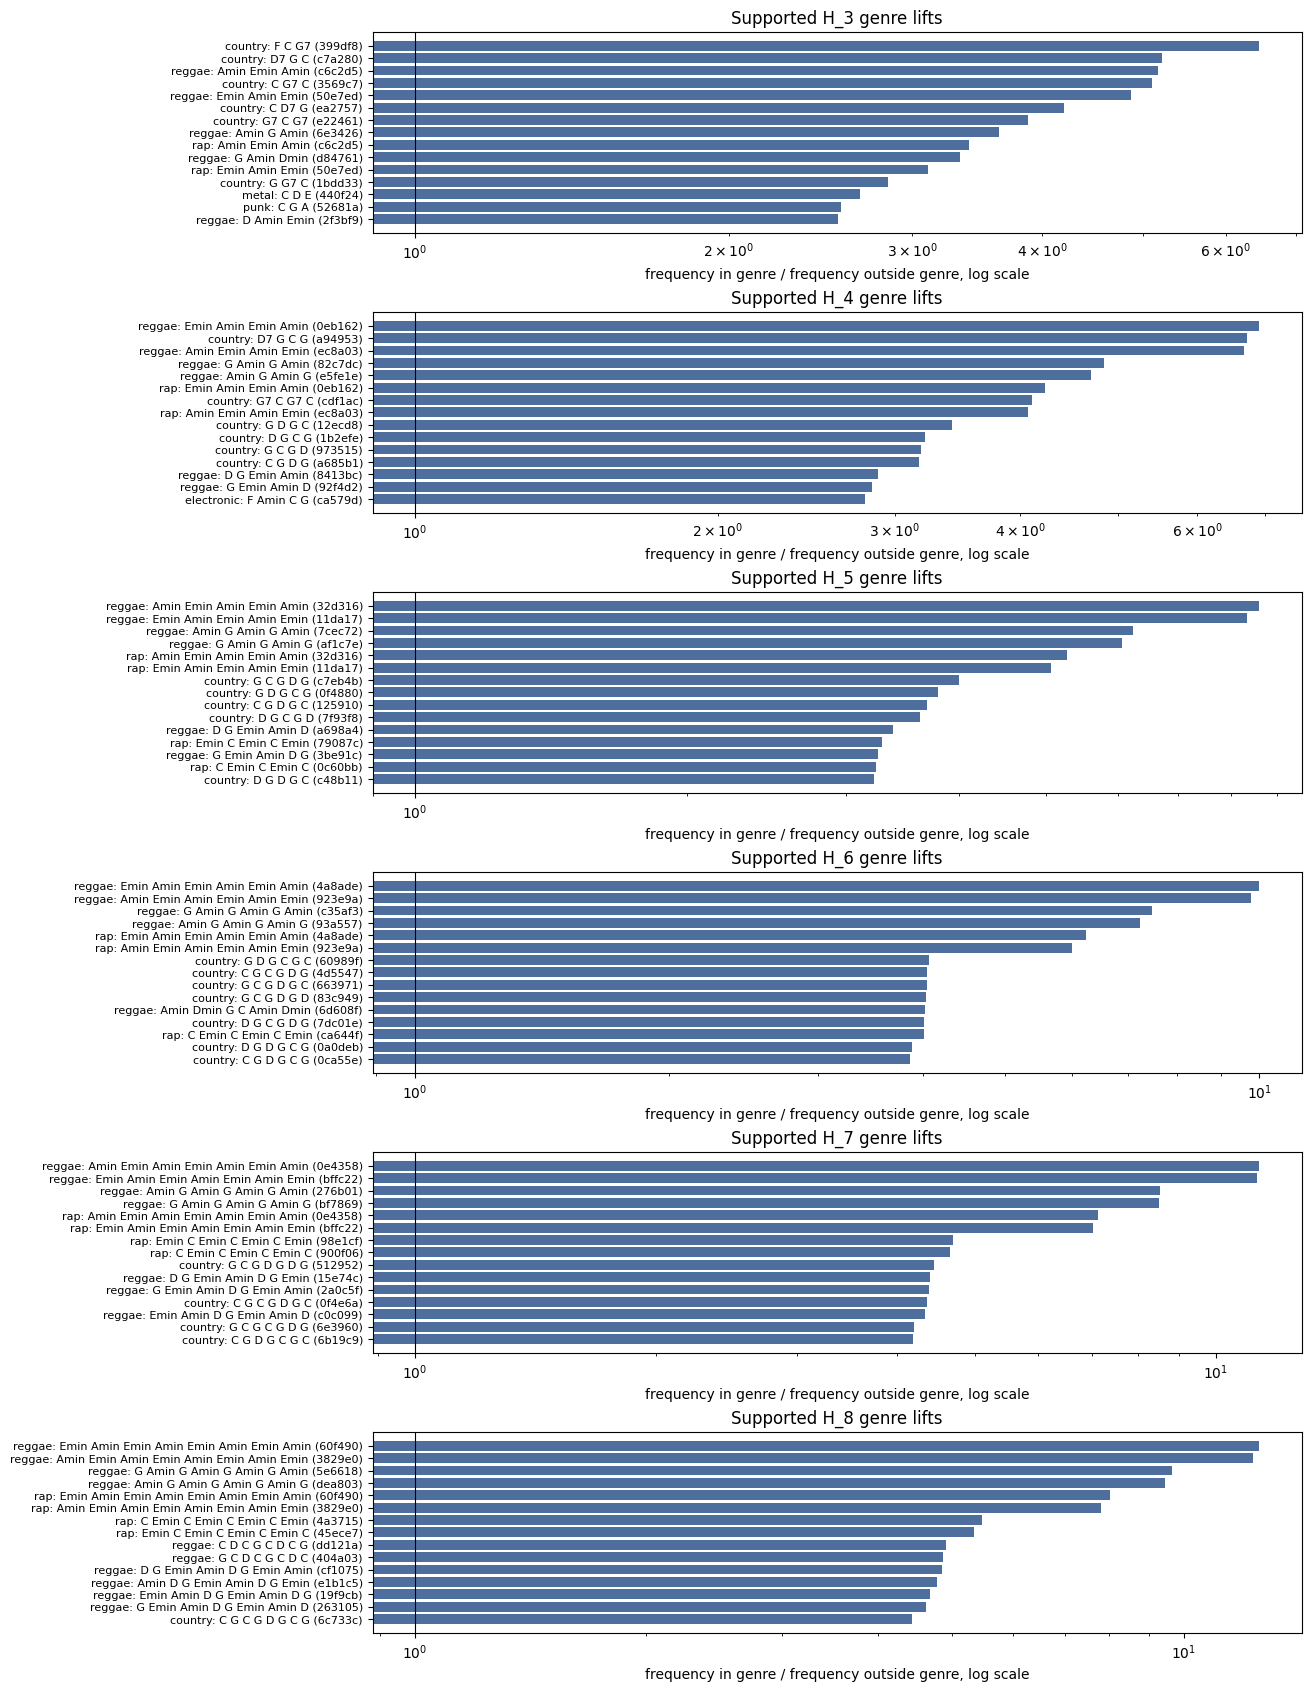

In [11]:
plot_df = supported_genre_top.copy()
plot_df["label"] = [
    f"{genre}: {short_harmonic_label(example, harmonic_id)}"
    for genre, example, harmonic_id in zip(
        plot_df["main_genre"],
        plot_df["representative_example_ngram"],
        plot_df["harmonic_id"],
    )
]

fig, axes = plt.subplots(len(NS), 1, figsize=(13, 2.8 * len(NS)), constrained_layout=True)
if len(NS) == 1:
    axes = [axes]

for ax, n in zip(axes, NS):
    sub = plot_df[plot_df["n"] == n].sort_values("genre_lift")
    if sub.empty:
        ax.set_title(f"No supported H_{n} genre lifts with current filters")
        ax.axis("off")
        continue
    ax.barh(sub["label"], sub["genre_lift"], color="#4e6f9e")
    ax.axvline(1, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_title(f"Supported H_{n} genre lifts")
    ax.set_xlabel("frequency in genre / frequency outside genre, log scale")
    ax.tick_params(axis="y", labelsize=8)

plt.show()

## Visual Summary: Family-Level Changes

These plots are the report-facing version of the detailed `H_n` plots: one bar per family, with `n_values` showing which n-gram lengths contributed.


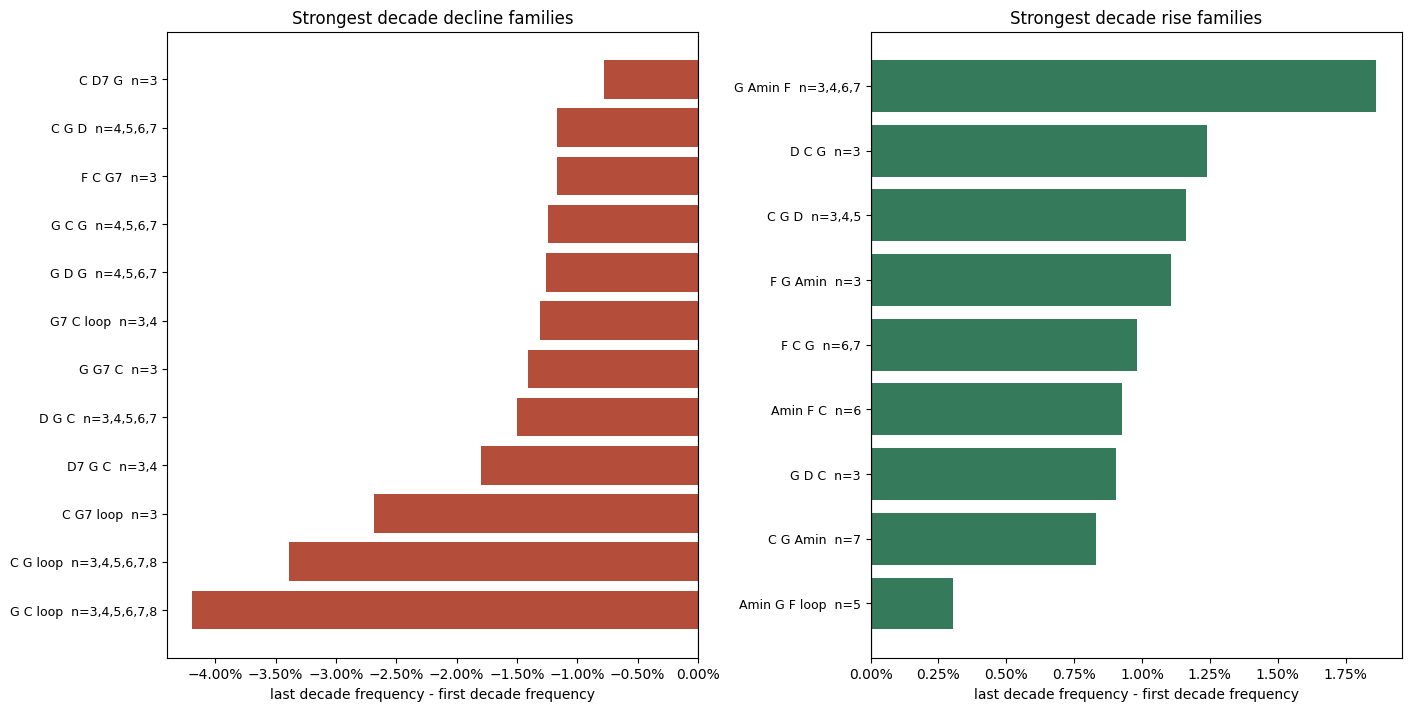

In [12]:
plot_df = decade_trend_families.copy()
plot_df["plot_label"] = plot_df["family_label"] + "  n=" + plot_df["n_values"]
plot_df = (
    plot_df.sort_values("max_abs_delta", ascending=False)
    .groupby("trend_direction", as_index=False)
    .head(12)
    .sort_values(["trend_direction", "frequency_delta"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, direction, color in zip(axes, ["decline", "rise"], ["#b44e3a", "#347a5b"]):
    sub = plot_df[plot_df["trend_direction"] == direction].sort_values("frequency_delta")
    if sub.empty:
        ax.set_title(f"No supported {direction} families")
        ax.axis("off")
        continue
    ax.barh(sub["plot_label"], sub["frequency_delta"], color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Strongest decade {direction} families")
    ax.set_xlabel("last decade frequency - first decade frequency")
    ax.tick_params(axis="y", labelsize=9)

plt.show()


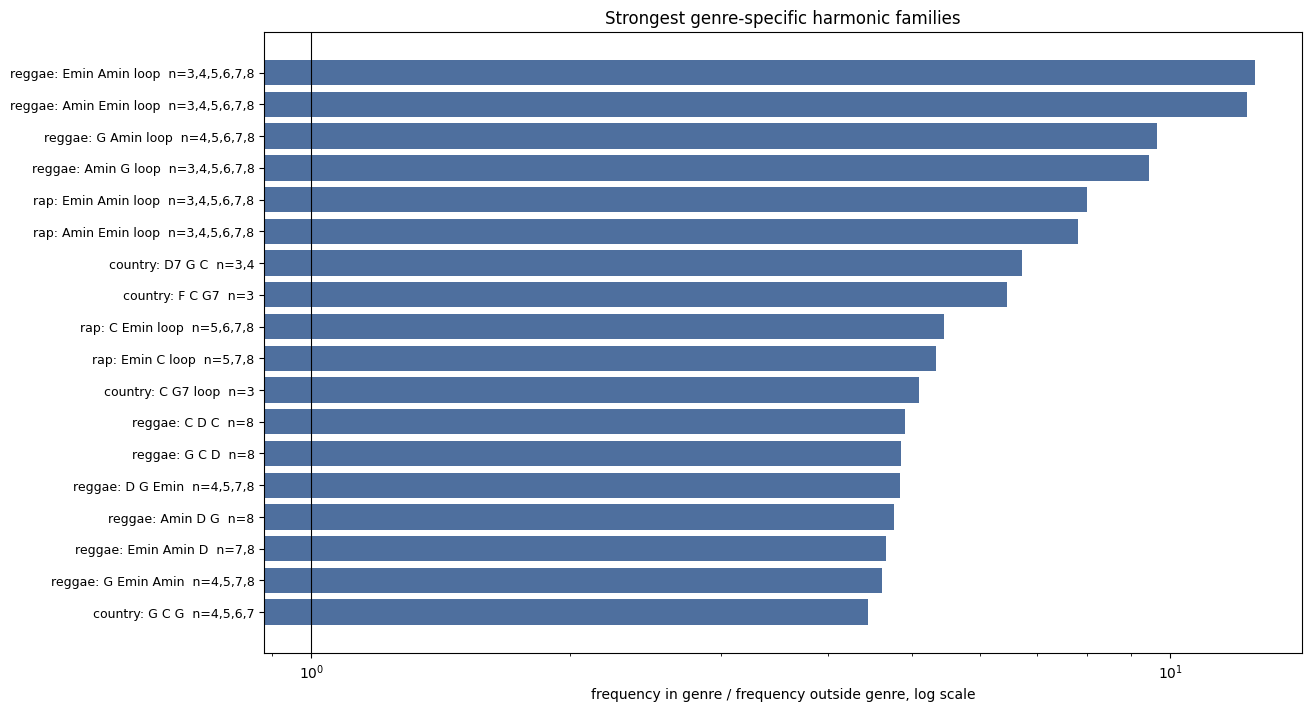

In [13]:
plot_df = genre_trend_families.copy()
plot_df["plot_label"] = plot_df["main_genre"] + ": " + plot_df["family_label"] + "  n=" + plot_df["n_values"]
plot_df = plot_df.sort_values("max_genre_lift", ascending=False).head(18).sort_values("max_genre_lift")

fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=True)
if plot_df.empty:
    ax.set_title("No supported genre-specific families with current filters")
    ax.axis("off")
else:
    ax.barh(plot_df["plot_label"], plot_df["max_genre_lift"], color="#4e6f9e")
    ax.axvline(1, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_title("Strongest genre-specific harmonic families")
    ax.set_xlabel("frequency in genre / frequency outside genre, log scale")
    ax.tick_params(axis="y", labelsize=9)

plt.show()


## Exact Representatives Inside Top Harmonic Classes

This shows how the most frequent harmonic class for each `n` splits into exact chord-token representatives by genre. It helps identify whether a harmonic trend is broad or dominated by one exact spelling/key.

In [14]:
top_rep_by_genre = (
    representatives_by_genre
    .sort_values(["n", "main_genre", "exact_count"], ascending=[True, True, False])
    .groupby(["n", "main_genre"], as_index=False)
    .head(5)
)

top_rep_by_genre

,n,main_genre,ngram,exact_ngram_id,exact_count,harmonic_count,exact_frequency,harmonic_frequency,exact_count_share_within_H
0,3,alternative,G C G,3_ce87d78ae19f8322,33398,137104,0.009673,0.039711,0.243596
1,3,alternative,C F C,3_777c093b9cc665f8,23875,137104,0.006915,0.039711,0.174138
2,3,alternative,D G D,3_fe4dbe8dc705a25b,20116,137104,0.005826,0.039711,0.146721
3,3,alternative,E A E,3_666a7630422963ab,16134,137104,0.004673,0.039711,0.117677
4,3,alternative,A D A,3_2ed1bbbae7af8d62,16032,137104,0.004644,0.039711,0.116933
...,...,...,...,...,...,...,...,...,...
367,8,soul,G D Emin C G D Emin C,8_f433bd6b288fdb24,433,1287,0.000838,0.002490,0.336441
368,8,soul,C G Amin F C G Amin F,8_a993930203ba4d88,355,1287,0.000687,0.002490,0.275835
369,8,soul,D A Bmin G D A Bmin G,8_29eaadf45d796758,107,1287,0.000207,0.002490,0.083139
370,8,soul,E B Csmin A E B Csmin A,8_1dadc10370ae160a,88,1287,0.000170,0.002490,0.068376


## Exact-vs-Harmonic Divergence Candidates

High-share rows show exact progressions that dominate their harmonic class in a stratum. Low-share rows show exact progressions that appear within a common harmonic class but account for little of it.

In [15]:
high_share_supported = high_share[high_share["exact_count"] >= MIN_SUPPORT_COUNT].copy()
low_share_supported = low_share[low_share["exact_count"] >= MIN_SUPPORT_COUNT].copy()

high_share_supported = high_share_supported.sort_values(["n", "exact_share_of_harmonic_frequency"], ascending=[True, False])
low_share_supported = low_share_supported.sort_values(["n", "exact_share_of_harmonic_frequency"], ascending=[True, True])

high_share_supported, low_share_supported

(    stratum_type stratum_value  n      exact_ngram_id                        ngram          harmonic_id  exact_count  harmonic_count  total_windows  exact_frequency  \
 10    main_genre       country  3  3_d10ab3f65d67c84e                  Amin G Amin  H3_6e3426e5386b2a67         9190           21315        3693669         0.002488   
 12          year          1994  3  3_a3e182361eb1cf40                     Amin C G  H3_4e2fdb872fee09bf          911            2142         265662         0.003429   
 21          year          1989  3  3_d10ab3f65d67c84e                  Amin G Amin  H3_6e3426e5386b2a67          572            1444         187601         0.003049   
 22          year          1992  3  3_fbd0124aa3bdaecf                     G Emin C  H3_3e9c3606c3db09c1          672            1704         228303         0.002943   
 24    main_genre       country  3  3_a3e182361eb1cf40                     Amin C G  H3_4e2fdb872fee09bf        14304           36477        3693669       

## Family Findings to Inspect Manually

This is the compact reading list. It is grouped by harmonic family, so repeated `n` variants support the same finding instead of cluttering the interpretation.


In [16]:
family_findings = []

for row in decade_trend_families[decade_trend_families["trend_direction"] == "decline"].head(10).itertuples(index=False):
    family_findings.append(
        {
            "category": "decade_decline_family",
            "family_label": row.family_label,
            "family_kind": row.family_kind,
            "n_values": row.n_values,
            "best_n": row.n,
            "best_example": row.representative_example_ngram,
            "harmonic_id": row.harmonic_id,
            "summary": f"{row.first_frequency:.2%} in {row.first_decade} -> {row.last_frequency:.2%} in {row.last_decade}",
            "support": f"endpoint counts {row.first_count:,} -> {row.last_count:,}; {row.n_rows} related rows",
        }
    )

for row in decade_trend_families[decade_trend_families["trend_direction"] == "rise"].head(10).itertuples(index=False):
    family_findings.append(
        {
            "category": "decade_rise_family",
            "family_label": row.family_label,
            "family_kind": row.family_kind,
            "n_values": row.n_values,
            "best_n": row.n,
            "best_example": row.representative_example_ngram,
            "harmonic_id": row.harmonic_id,
            "summary": f"{row.first_frequency:.2%} in {row.first_decade} -> {row.last_frequency:.2%} in {row.last_decade}",
            "support": f"endpoint counts {row.first_count:,} -> {row.last_count:,}; {row.n_rows} related rows",
        }
    )

for row in genre_trend_families.sort_values("max_genre_lift", ascending=False).head(15).itertuples(index=False):
    family_findings.append(
        {
            "category": "genre_specific_family",
            "family_label": row.family_label,
            "family_kind": row.family_kind,
            "n_values": row.n_values,
            "best_n": row.n,
            "best_example": row.representative_example_ngram,
            "harmonic_id": row.harmonic_id,
            "summary": f"{row.main_genre} lift {row.genre_lift:.2f}x",
            "support": f"count {row.count:,}, windows {row.total_windows:,}; {row.n_rows} related rows",
        }
    )

family_findings = pd.DataFrame(family_findings)
family_findings


,category,family_label,family_kind,n_values,best_n,best_example,harmonic_id,summary,support
0,decade_decline_family,G C loop,loop,"3,4,5,6,7,8",3,G C G,H3_ede3c4f53675bbb0,7.80% in 1950 -> 3.61% in 2020,"endpoint counts 7,478 -> 150,418; 6 related rows"
1,decade_decline_family,C G loop,loop,"3,4,5,6,7,8",3,C G C,H3_35d6bfda85b78e3b,6.54% in 1950 -> 3.16% in 2020,"endpoint counts 6,277 -> 131,781; 6 related rows"
2,decade_decline_family,C G7 loop,loop,3,3,C G7 C,H3_3569c7a41696606d,2.85% in 1950 -> 0.16% in 2020,"endpoint counts 2,732 -> 6,701; 1 related rows"
3,decade_decline_family,D7 G C,phrase,"3,4",3,D7 G C,H3_c7a280c94f7b2c52,1.95% in 1950 -> 0.15% in 2020,"endpoint counts 1,867 -> 6,200; 2 related rows"
4,decade_decline_family,D G C,phrase,"3,4,5,6,7",3,D G C,H3_614d8a0823c338e1,3.50% in 1950 -> 2.00% in 2020,"endpoint counts 3,353 -> 83,397; 6 related rows"
5,decade_decline_family,G G7 C,phrase,3,3,G G7 C,H3_1bdd33c6de808e91,1.59% in 1950 -> 0.18% in 2020,"endpoint counts 1,527 -> 7,632; 1 related rows"
6,decade_decline_family,G7 C loop,loop,"3,4",3,G7 C G7,H3_e22461c759d5715e,1.39% in 1950 -> 0.08% in 2020,"endpoint counts 1,333 -> 3,448; 2 related rows"
7,decade_decline_family,G D G,phrase,"4,5,6,7",4,G D G C,H4_12ecd8ebdeaeb0cb,1.75% in 1950 -> 0.50% in 2020,"endpoint counts 1,651 -> 20,484; 4 related rows"
8,decade_decline_family,G C G,phrase,"4,5,6,7",4,G C G D,H4_973515a9446c761a,1.91% in 1950 -> 0.67% in 2020,"endpoint counts 1,798 -> 27,457; 4 related rows"
9,decade_decline_family,F C G7,phrase,3,3,F C G7,H3_399df86a5aae7301,1.25% in 1950 -> 0.08% in 2020,"endpoint counts 1,196 -> 3,309; 1 related rows"


## Export Interpretation Tables

These are small, report-oriented tables. They do not replace the DuckDB database or notebook 5 outputs.

In [17]:
OUT_DIR = ROOT / "data" / "processed" / "interpretation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "largest_declines": OUT_DIR / "largest_supported_decade_declines.csv",
    "largest_rises": OUT_DIR / "largest_supported_decade_rises.csv",
    "supported_genre": OUT_DIR / "supported_genre_specific_harmonic_classes.csv",
    "decade_trend_families": OUT_DIR / "decade_trend_families.csv",
    "genre_trend_families": OUT_DIR / "genre_trend_families.csv",
    "top_rep_by_genre": OUT_DIR / "top_representatives_by_genre.csv",
    "high_share_supported": OUT_DIR / "supported_exact_harmonic_high_share.csv",
    "low_share_supported": OUT_DIR / "supported_exact_harmonic_low_share.csv",
    "family_findings": OUT_DIR / "family_findings.csv",
    "candidate_findings": OUT_DIR / "candidate_findings.csv",
}

largest_declines.to_csv(paths["largest_declines"], index=False)
largest_rises.to_csv(paths["largest_rises"], index=False)
supported_genre_top.to_csv(paths["supported_genre"], index=False)
decade_trend_families.to_csv(paths["decade_trend_families"], index=False)
genre_trend_families.to_csv(paths["genre_trend_families"], index=False)
top_rep_by_genre.to_csv(paths["top_rep_by_genre"], index=False)
high_share_supported.to_csv(paths["high_share_supported"], index=False)
low_share_supported.to_csv(paths["low_share_supported"], index=False)
family_findings.to_csv(paths["family_findings"], index=False)
family_findings.to_csv(paths["candidate_findings"], index=False)

paths


{'largest_declines': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/largest_supported_decade_declines.csv'),
 'largest_rises': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/largest_supported_decade_rises.csv'),
 'supported_genre': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/supported_genre_specific_harmonic_classes.csv'),
 'decade_trend_families': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/decade_trend_families.csv'),
 'genre_trend_families': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/genre_trend_families.csv'),
 'top_rep_by_genre': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/interpretation/top_representatives_by_genre.csv'),
 'high_share_supported': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/da

## Next Directions

Good next steps:

- Use `family_findings.csv` as the short reading list.
- Use `decade_trend_families.csv` and `genre_trend_families.csv` for report plots and prose.
- Use the detailed `largest_*`, `supported_genre_*`, and representative tables when a family needs audit detail.
- Add uncertainty estimates for frequency deltas and genre lift before making final claims.
- Start geometry with a filtered `H_n` subset, not all pairs. A practical first pass is `count >= 1000` or top-k per `n`, then compute nearest neighbors under L2 on reconstructed `12 x n` matrices.
- Treat Levenshtein distance as a separate design choice: decide whether edits operate on exact chord tokens, harmonic columns, or family labels before writing the distance table.
- Move to full distance analysis only after the metric definitions and candidate set are stable.


## Handoff

Use this notebook's outputs as manually inspectable candidate findings among globally common harmonic classes.

Notebook 7 starts a separate artifact-building step for broad document-term counts. Notebook 8 then applies corpus-linguistic statistics to those counts.